# Evaluation

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
plt.style.use("default")

from evaluate import compute_accuracy_df, compute_accuracy_difference, get_plot_dict, get_plot_dict_stacked, get_plot_dict_cum
from evaluate import extract_answers
from evaluate import run_test_categorical, test_flores, run_test_dynamic, run_test_static, test_static_vs_dynamic
from evaluate import PlottingWrapper
from dotenv import load_dotenv

load_dotenv()

True

## Helpers

In [82]:
from inference.evaluator import Evaluator

dataset_path = "gpt-5_0-nano"
evaluator = Evaluator(dataset_path=dataset_path)

persona_registry = evaluator.get_persona_registry()
answer_columns = persona_registry.get_answer_columns()
completion_columns = [col.replace("_answer", "") for col in answer_columns]

# del_personas = ["helpful" , "static_short", "static_long"]
# completion_columns = [c for c in completion_columns if c not in del_personas]

plotting_wrapper = PlottingWrapper(completion_columns)

2026-02-19 12:32:10  INFO     dataset_handler:_load               Preparing datasets
2026-02-19 12:32:10  INFO     dataset_handler:_download_dataset   Loading mmlu-pro
2026-02-19 12:32:11  INFO     dataset_handler:_download_dataset   Selecting a subset of 200 samples per category for category
2026-02-19 12:32:11  INFO     dataset_handler:_download_dataset   Dataframe length: 2800
2026-02-19 12:32:11  INFO     dataset_handler:_download_dataset   Loading MATH
2026-02-19 12:32:11  INFO     dataset_handler:_download_dataset   Selecting a subset of 200 samples per category for subject
2026-02-19 12:32:11  INFO     dataset_handler:_download_dataset   Dataframe length: 500
2026-02-19 12:32:11  INFO     dataset_handler:_download_dataset   Loading flores
2026-02-19 12:32:11  INFO     dataset_handler:_download_dataset   Selecting a subset of 200 samples per category for iso_639_3
2026-02-19 12:32:11  INFO     dataset_handler:_download_dataset   Dataframe length: 41400


In [67]:
extraction_columns = [f"{x}_option" for x in answer_columns]

In [68]:
length_dynamic_cols = [
    "base",
    "dynamic_short",
    "dynamic_long",
    "helpful_answer_option",
    "static_short_answer_option",
    "static_long_answer_option",
    "beginner_teacher_answer_option",
    "intermediate_teacher_answer_option",
    "expert_teacher_answer_option",
]

# 1. persona vs. baseline
# 2. measuring effects of properties with regression
# 3. static vs. dynamic
# for discussion: findings between open and closed
# find title!!
# no acknowledgments
# next meeting: 14.01.2025 @ 14:00

## MMLU Evaluation

In [69]:
mmlu_tasks, mmlu_df = evaluator.get_data("mmlu-pro")
mmlu_df = extract_answers(mmlu_df, answer_columns, "mmlu")

In [70]:
accuracy_df = compute_accuracy_df(mmlu_df, completion_columns)
gains_baseline_df = compute_accuracy_difference(accuracy_df, "no")
gains_helpful_df = compute_accuracy_difference(accuracy_df, "helpful")

<>:13: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_26588/1757931487.py:13: SyntaxWarning: invalid escape sequence '\D'
  plotting_wrapper.plot_rel_accuracy(axes[1], accuracy_diffs, title="(b) $\Delta$ accuracy vs. baseline (%)")


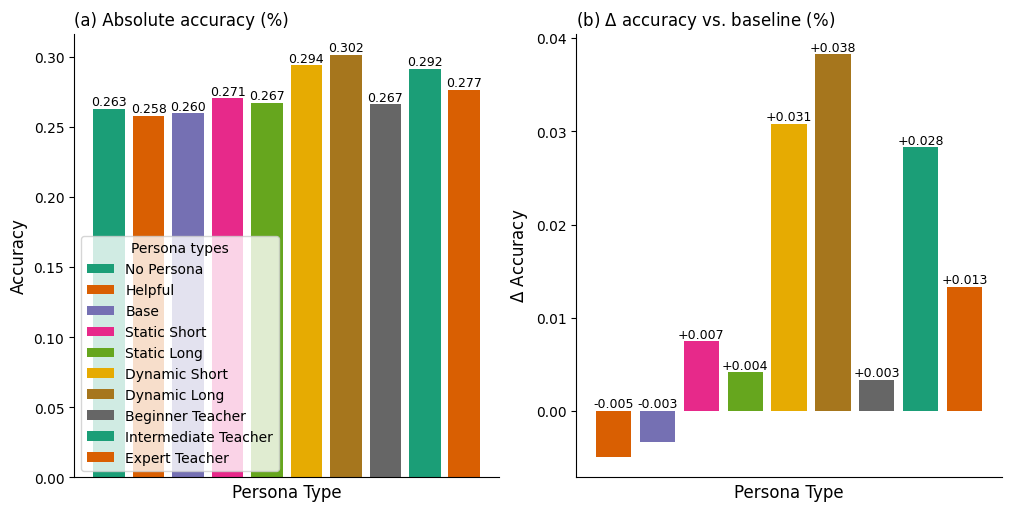

In [71]:
# Plot with only no persona and across all categories
absolute_accuracy = accuracy_df.mean(numeric_only=True).to_dict()
accuracy_diffs = gains_baseline_df.mean(numeric_only=True).to_dict()

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5),
    constrained_layout=True
)

plotting_wrapper.plot_abs_accuracy(axes[0], absolute_accuracy, title="(a) Absolute accuracy (%)")
plotting_wrapper.plot_rel_accuracy(axes[1], accuracy_diffs, title="(b) $\Delta$ accuracy vs. baseline (%)")

fig.savefig(f"plots/mmlu-pro_{dataset_path}_average", dpi=1200)
plt.show()

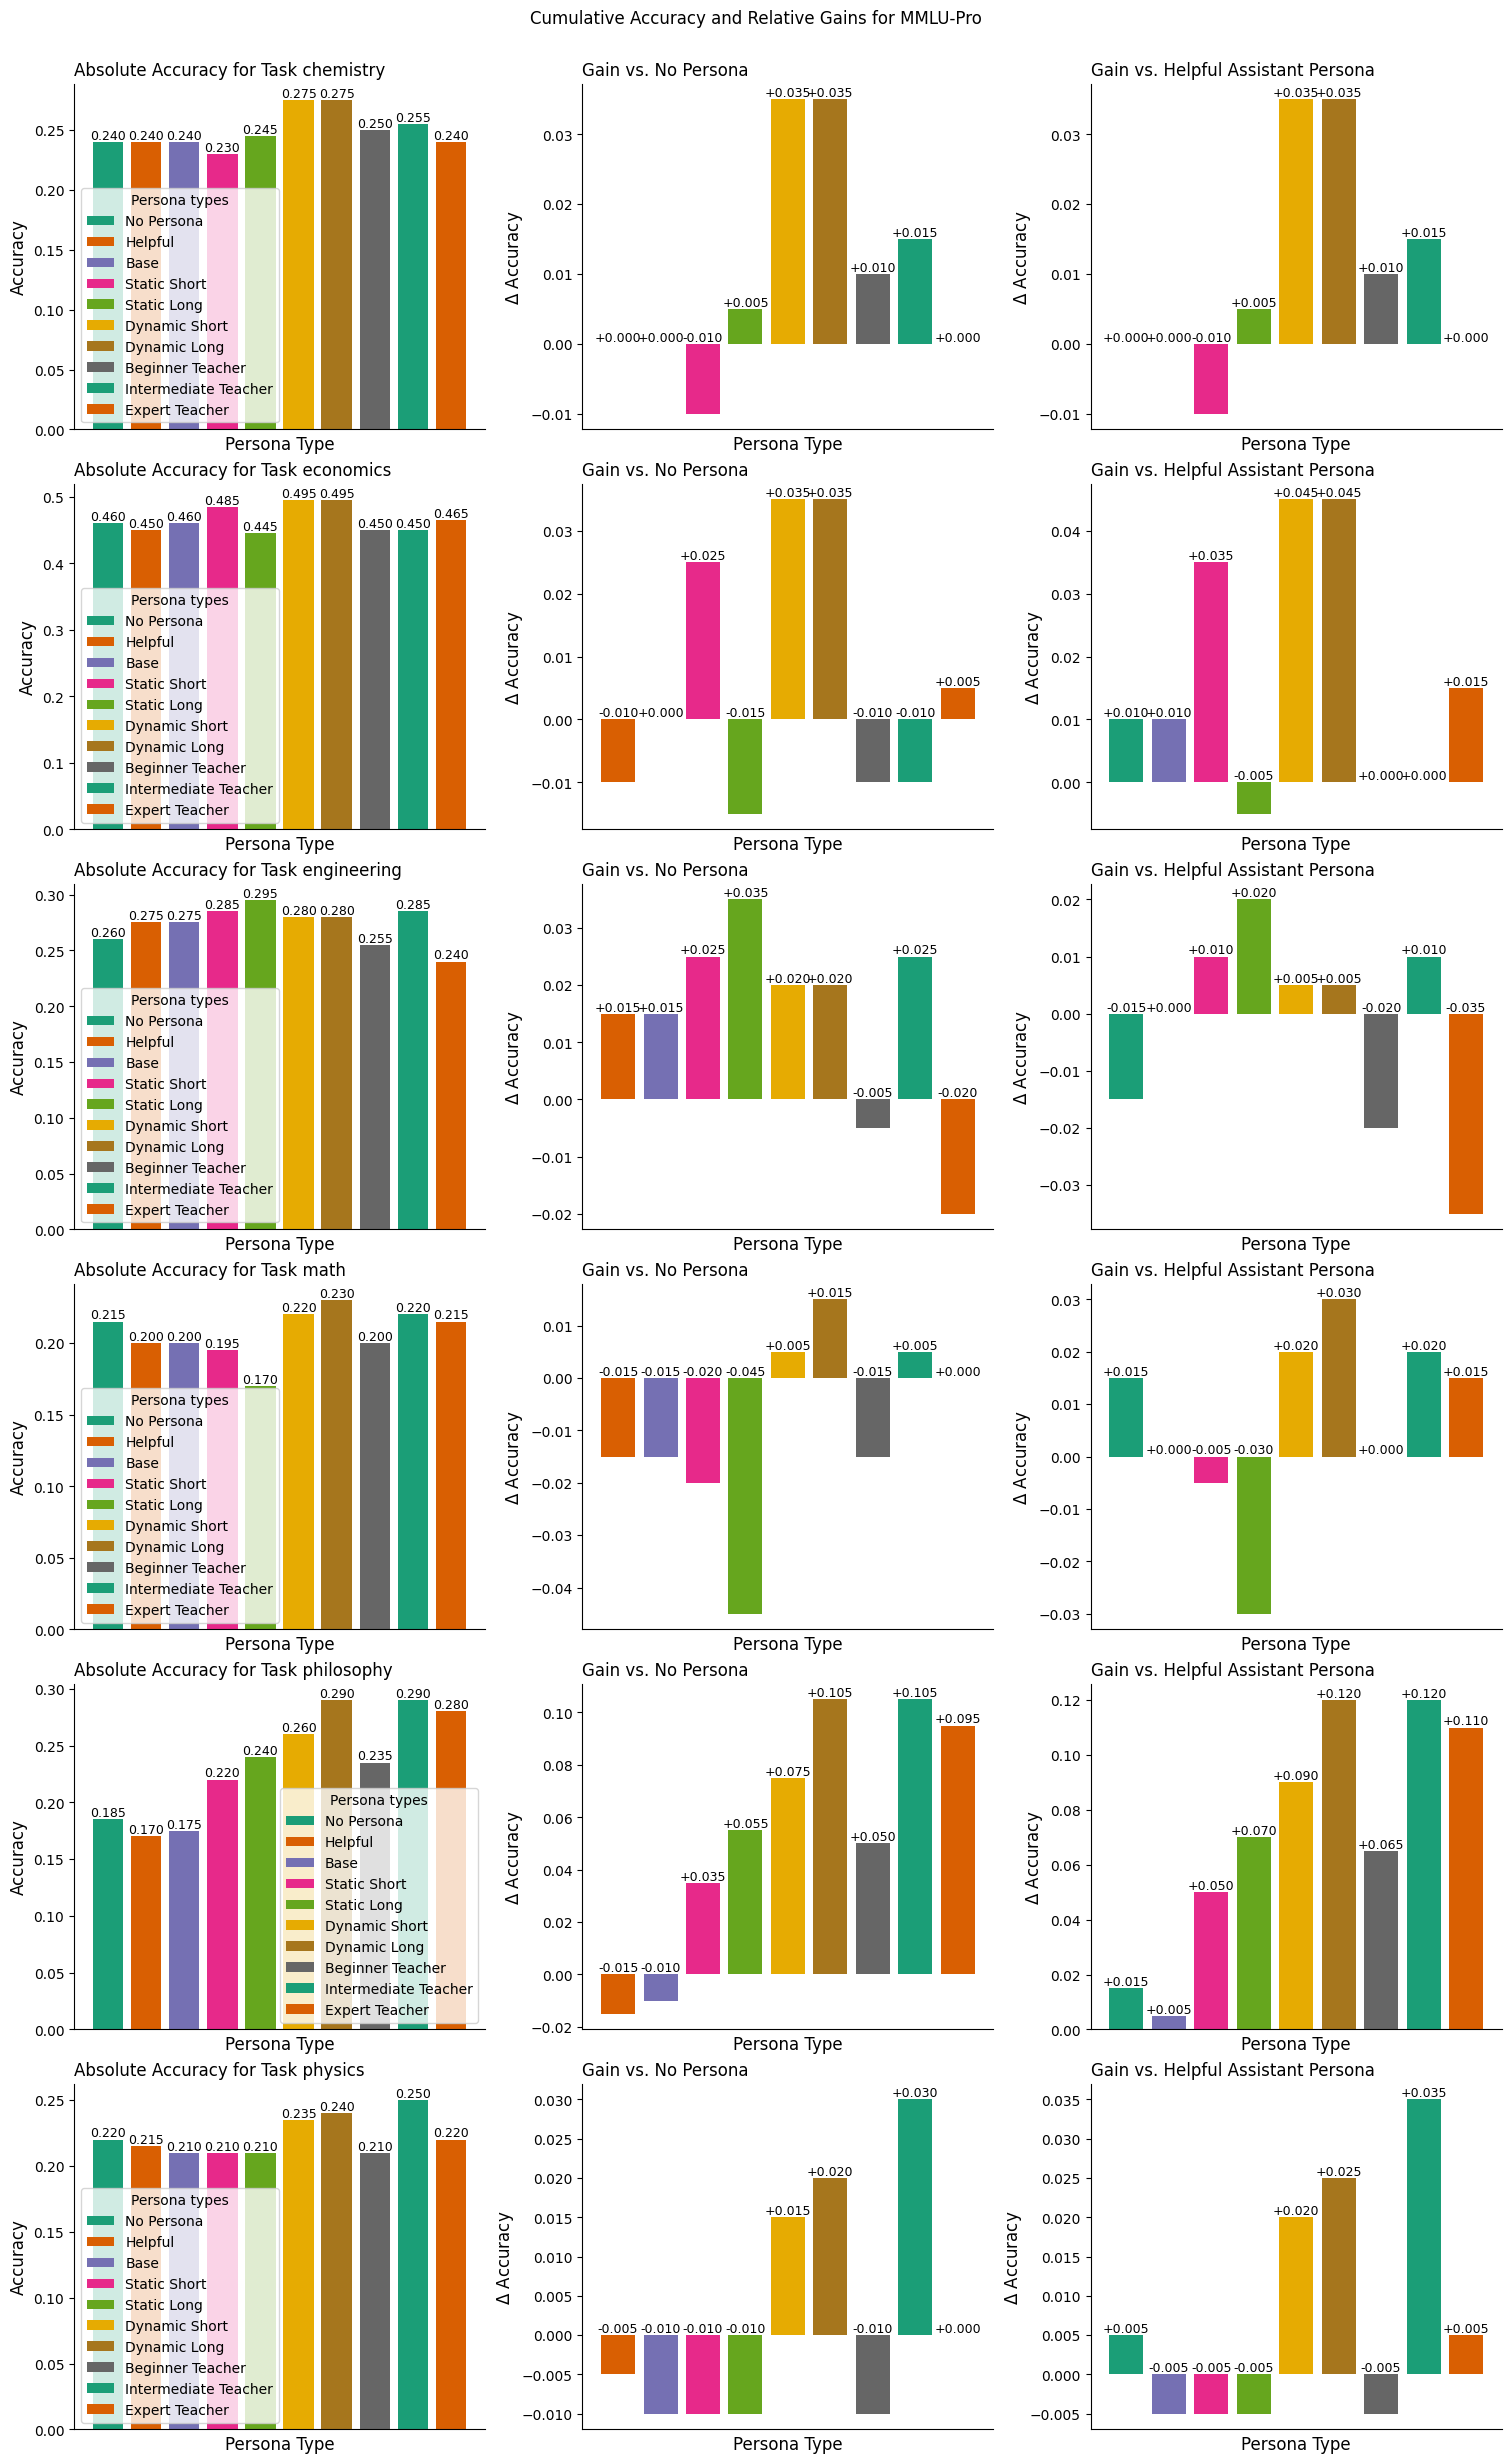

In [72]:
categories = accuracy_df["category"].tolist()

fig, axes = plt.subplots(
    nrows=len(categories),
    ncols=3,
    figsize=(15, len(categories) * 4),
    constrained_layout=True
)

for i, category in enumerate(categories):
    row_abs = get_plot_dict(accuracy_df, category, ignore_cols=["category"])
    row_base = get_plot_dict(gains_baseline_df, category, ignore_cols=["no"])
    row_help = get_plot_dict(gains_helpful_df, category, ignore_cols=["helpful"])

    plotting_wrapper.plot_abs_accuracy(axes[i][0], row_abs, title=f"Absolute Accuracy for Task {category}")
    plotting_wrapper.plot_rel_accuracy(axes[i][1], row_base, title=f"Gain vs. No Persona")
    plotting_wrapper.plot_rel_accuracy(axes[i][2], row_help, title=f"Gain vs. Helpful Assistant Persona")

fig.suptitle("Cumulative Accuracy and Relative Gains for MMLU-Pro", y=1.02)
fig.savefig(f"plots/mmlu-pro_{dataset_path}", dpi=1200)
plt.show()

In [25]:
mmlu_effects_df = mmlu_df.copy()
for col in completion_columns:
    eq_col = mmlu_effects_df["answer"] == mmlu_effects_df[col]
    mmlu_effects_df[col] = eq_col.astype("int")

### Category chemistry

In [26]:
run_test_categorical(mmlu_effects_df, completion_columns, "chemistry")

0
base                    0.620191
beginner_teacher        0.868792
dynamic_long            0.069198
dynamic_short           0.013216
expert_teacher          0.186319
helpful                 1.000000
intermediate_teacher    0.321607
static_long             0.868792
static_short            0.868792
dtype: float64

In [27]:
run_test_dynamic(mmlu_effects_df, "chemistry")

persona    0.440741
dtype: float64

In [29]:
run_test_static(mmlu_effects_df, "chemistry")

persona    0.784086
dtype: float64

In [30]:
test_static_vs_dynamic(mmlu_effects_df, "chemistry")

is_dynamic    0.004223
dtype: float64

### Category economics

In [31]:
run_test_categorical(mmlu_effects_df, completion_columns, "economics")

0
base                    0.096645
beginner_teacher        0.139743
dynamic_long            0.026752
dynamic_short           0.711988
expert_teacher          0.711988
helpful                 0.096645
intermediate_teacher    0.711988
static_long             0.579729
static_short            0.853548
dtype: float64

In [32]:
run_test_dynamic(mmlu_effects_df, "economics")

persona    0.000571
dtype: float64

In [33]:
run_test_static(mmlu_effects_df, "economics")

persona    0.502074
dtype: float64

In [34]:
test_static_vs_dynamic(mmlu_effects_df, "economics")

is_dynamic    0.002681
dtype: float64

### Category math

In [35]:
run_test_categorical(mmlu_effects_df, completion_columns, "math")

0
base                    0.735727
beginner_teacher        1.000000
dynamic_long            0.612663
dynamic_short           0.612663
expert_teacher          0.865986
helpful                 0.735727
intermediate_teacher    0.612663
static_long             0.128805
static_short            0.398784
dtype: float64

In [36]:
run_test_dynamic(mmlu_effects_df, "math")

persona    0.330791
dtype: float64

In [37]:
run_test_static(mmlu_effects_df, "math")

persona    0.226209
dtype: float64

In [38]:
test_static_vs_dynamic(mmlu_effects_df, "math")

is_dynamic    0.169438
dtype: float64

### Category physics

In [39]:
run_test_categorical(mmlu_effects_df, completion_columns, "physics")

0
base                    0.871911
beginner_teacher        0.197101
dynamic_long            0.628602
dynamic_short           1.000000
expert_teacher          0.747101
helpful                 0.333348
intermediate_teacher    0.036081
static_long             0.076137
static_short            0.076137
dtype: float64

In [40]:
run_test_dynamic(mmlu_effects_df, "physics")

persona    0.49991
dtype: float64

In [41]:
run_test_static(mmlu_effects_df, "physics")

persona    0.081268
dtype: float64

In [42]:
test_static_vs_dynamic(mmlu_effects_df, "physics")

is_dynamic    0.148358
dtype: float64

### Category philosophy

In [43]:
run_test_categorical(mmlu_effects_df, completion_columns, "philosophy")

0
base                    0.581986
beginner_teacher        0.098645
dynamic_long            0.000024
dynamic_short           0.001812
expert_teacher          0.000116
helpful                 0.462960
intermediate_teacher    0.000054
static_long             0.027669
static_short            0.027669
dtype: float64

In [44]:
run_test_dynamic(mmlu_effects_df, "philosophy")

persona    0.001817
dtype: float64

In [45]:
run_test_static(mmlu_effects_df, "philosophy")

persona    0.153515
dtype: float64

In [46]:
test_static_vs_dynamic(mmlu_effects_df, "philosophy")

is_dynamic    0.002163
dtype: float64

### Category engineering

In [47]:
run_test_categorical(mmlu_effects_df, completion_columns, "engineering")

0
base                    0.877773
beginner_teacher        0.758397
dynamic_long            0.758397
dynamic_short           0.356133
expert_teacher          0.644526
helpful                 0.877773
intermediate_teacher    0.218568
static_long             0.124065
static_short            0.218568
dtype: float64

In [48]:
run_test_dynamic(mmlu_effects_df, "engineering")

persona    0.91808
dtype: float64

In [49]:
run_test_static(mmlu_effects_df, "engineering")

persona    0.040458
dtype: float64

In [50]:
test_static_vs_dynamic(mmlu_effects_df, "engineering")

is_dynamic    0.465888
dtype: float64

## MATH Evaluation

In [73]:
math_tasks, math_df = evaluator.get_data("MATH")

# Get rid of all whitespace in true answer
math_df.loc[:, "answers"] = math_df["answers"].str.replace(" ", "")
# Get rid of \text{...} wrapping
math_df.loc[:, "answers"] = math_df["answers"].str.replace(r"\\text\{(.*?)\}", r"\1", regex=True)

math_df = extract_answers(math_df, answer_columns, "math")

In [78]:
test_df = math_df.copy()

test_cols = []
for col in completion_columns:
    test_col = f"{col}_right"
    test_cols.append(test_col)
    test_df[test_col] = test_df["answers"] == test_df[col]

test_df[test_df[test_cols].eq(False).any(axis=1)]

,static_id,question,solution,answers,subject,level,unique_id,base_persona,static_short_persona,static_long_persona,...,no_right,helpful_right,base_right,static_short_right,static_long_right,dynamic_short_right,dynamic_long_right,beginner_teacher_right,intermediate_teacher_right,expert_teacher_right
0,MATH_301,$\textbf{Juan's Old Stamping Grounds}$\n\nJuan...,The $\text{70's}$ stamps cost:\n\n$\bullet$ B...,5.4cents,Prealgebra,5,test/prealgebra/1044.json,You are a prealgebra guide,You are a prealgebra guide who patiently expla...,You are a prealgebra guide who patiently expla...,...,False,False,False,False,False,False,False,False,False,False
1,MATH_94,"In quadrilateral $ABCD$, angle $BAD$ and angle...",Triangle $AFD$ must have a total angle measure...,80,Prealgebra,5,test/prealgebra/1646.json,You are a prealgebra guide,You are a prealgebra guide who patiently expla...,You are a prealgebra guide who patiently expla...,...,False,False,False,False,False,False,False,False,False,False
2,MATH_4,The results of a cross-country team's training...,Evelyn covered more distance in less time than...,Evelyn,Algebra,2,test/algebra/1349.json,You are an algebraic sage,You are an algebraic sage in the field of alge...,You are an algebraic sage in the field of alge...,...,False,False,False,False,True,False,False,False,False,False
3,MATH_281,"In regular pentagon $FGHIJ$, extending the sid...",The sum of the angle measures in a pentagon is...,36^\circ,Prealgebra,4,test/prealgebra/260.json,You are a prealgebra guide,You are a prealgebra guide who patiently expla...,You are a prealgebra guide who patiently expla...,...,False,False,False,False,False,False,False,False,False,False
4,MATH_392,The distances from a point $P$ to five of the ...,"Let $P = (x,y,z),$ and let the vertices of the...",\sqrt{66},Precalculus,5,test/precalculus/902.json,You are a/an precalculus mentor,You are a/an precalculus mentor who guides lea...,You are a/an precalculus mentor who guides lea...,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,MATH_54,Write $\frac{3}{20}$ as a decimal.,Multiplying numerator and denominator by 5 giv...,0.15,Prealgebra,2,test/prealgebra/572.json,You are a prealgebra guide,You are a prealgebra guide who patiently expla...,You are a prealgebra guide who patiently expla...,...,False,False,False,False,False,False,False,False,False,False
417,MATH_457,Determine the remainder of 54 (mod 6).,$54 = 9 \cdot 6 + 0 \Rightarrow 54 \equiv \box...,0,Number Theory,1,test/number_theory/342.json,You are a/an number theorist,You are a number theorist who sees the world t...,You are a number theorist who sees the world t...,...,False,False,False,False,False,False,False,False,False,False
418,MATH_350,Find the units digit of $18^6.$,The units digit of $18^6$ is the same as in $8...,4,Number Theory,2,test/number_theory/686.json,You are a/an number theorist,You are a number theorist who sees the world t...,You are a number theorist who sees the world t...,...,False,False,False,False,False,False,False,False,False,False
419,MATH_31,Simplify $\sqrt{242}$.,Factor 242 as $11^2 \cdot 2$. Then $\sqrt{242}...,11\sqrt2,Prealgebra,4,test/prealgebra/1302.json,You are a prealgebra guide,You are a prealgebra guide who patiently expla...,You are a prealgebra guide who patiently expla...,...,False,False,False,False,False,False,False,False,False,False


In [76]:
accuracy_df = compute_accuracy_df(math_df, completion_columns, ground_truth_col="answers", category_col="subject")
gains_baseline_df = compute_accuracy_difference(
    accuracy_df, "no", ["helpful"], category_col="subject")
gains_helpful_df = compute_accuracy_difference(
    accuracy_df, "helpful", ["no"], category_col="subject")

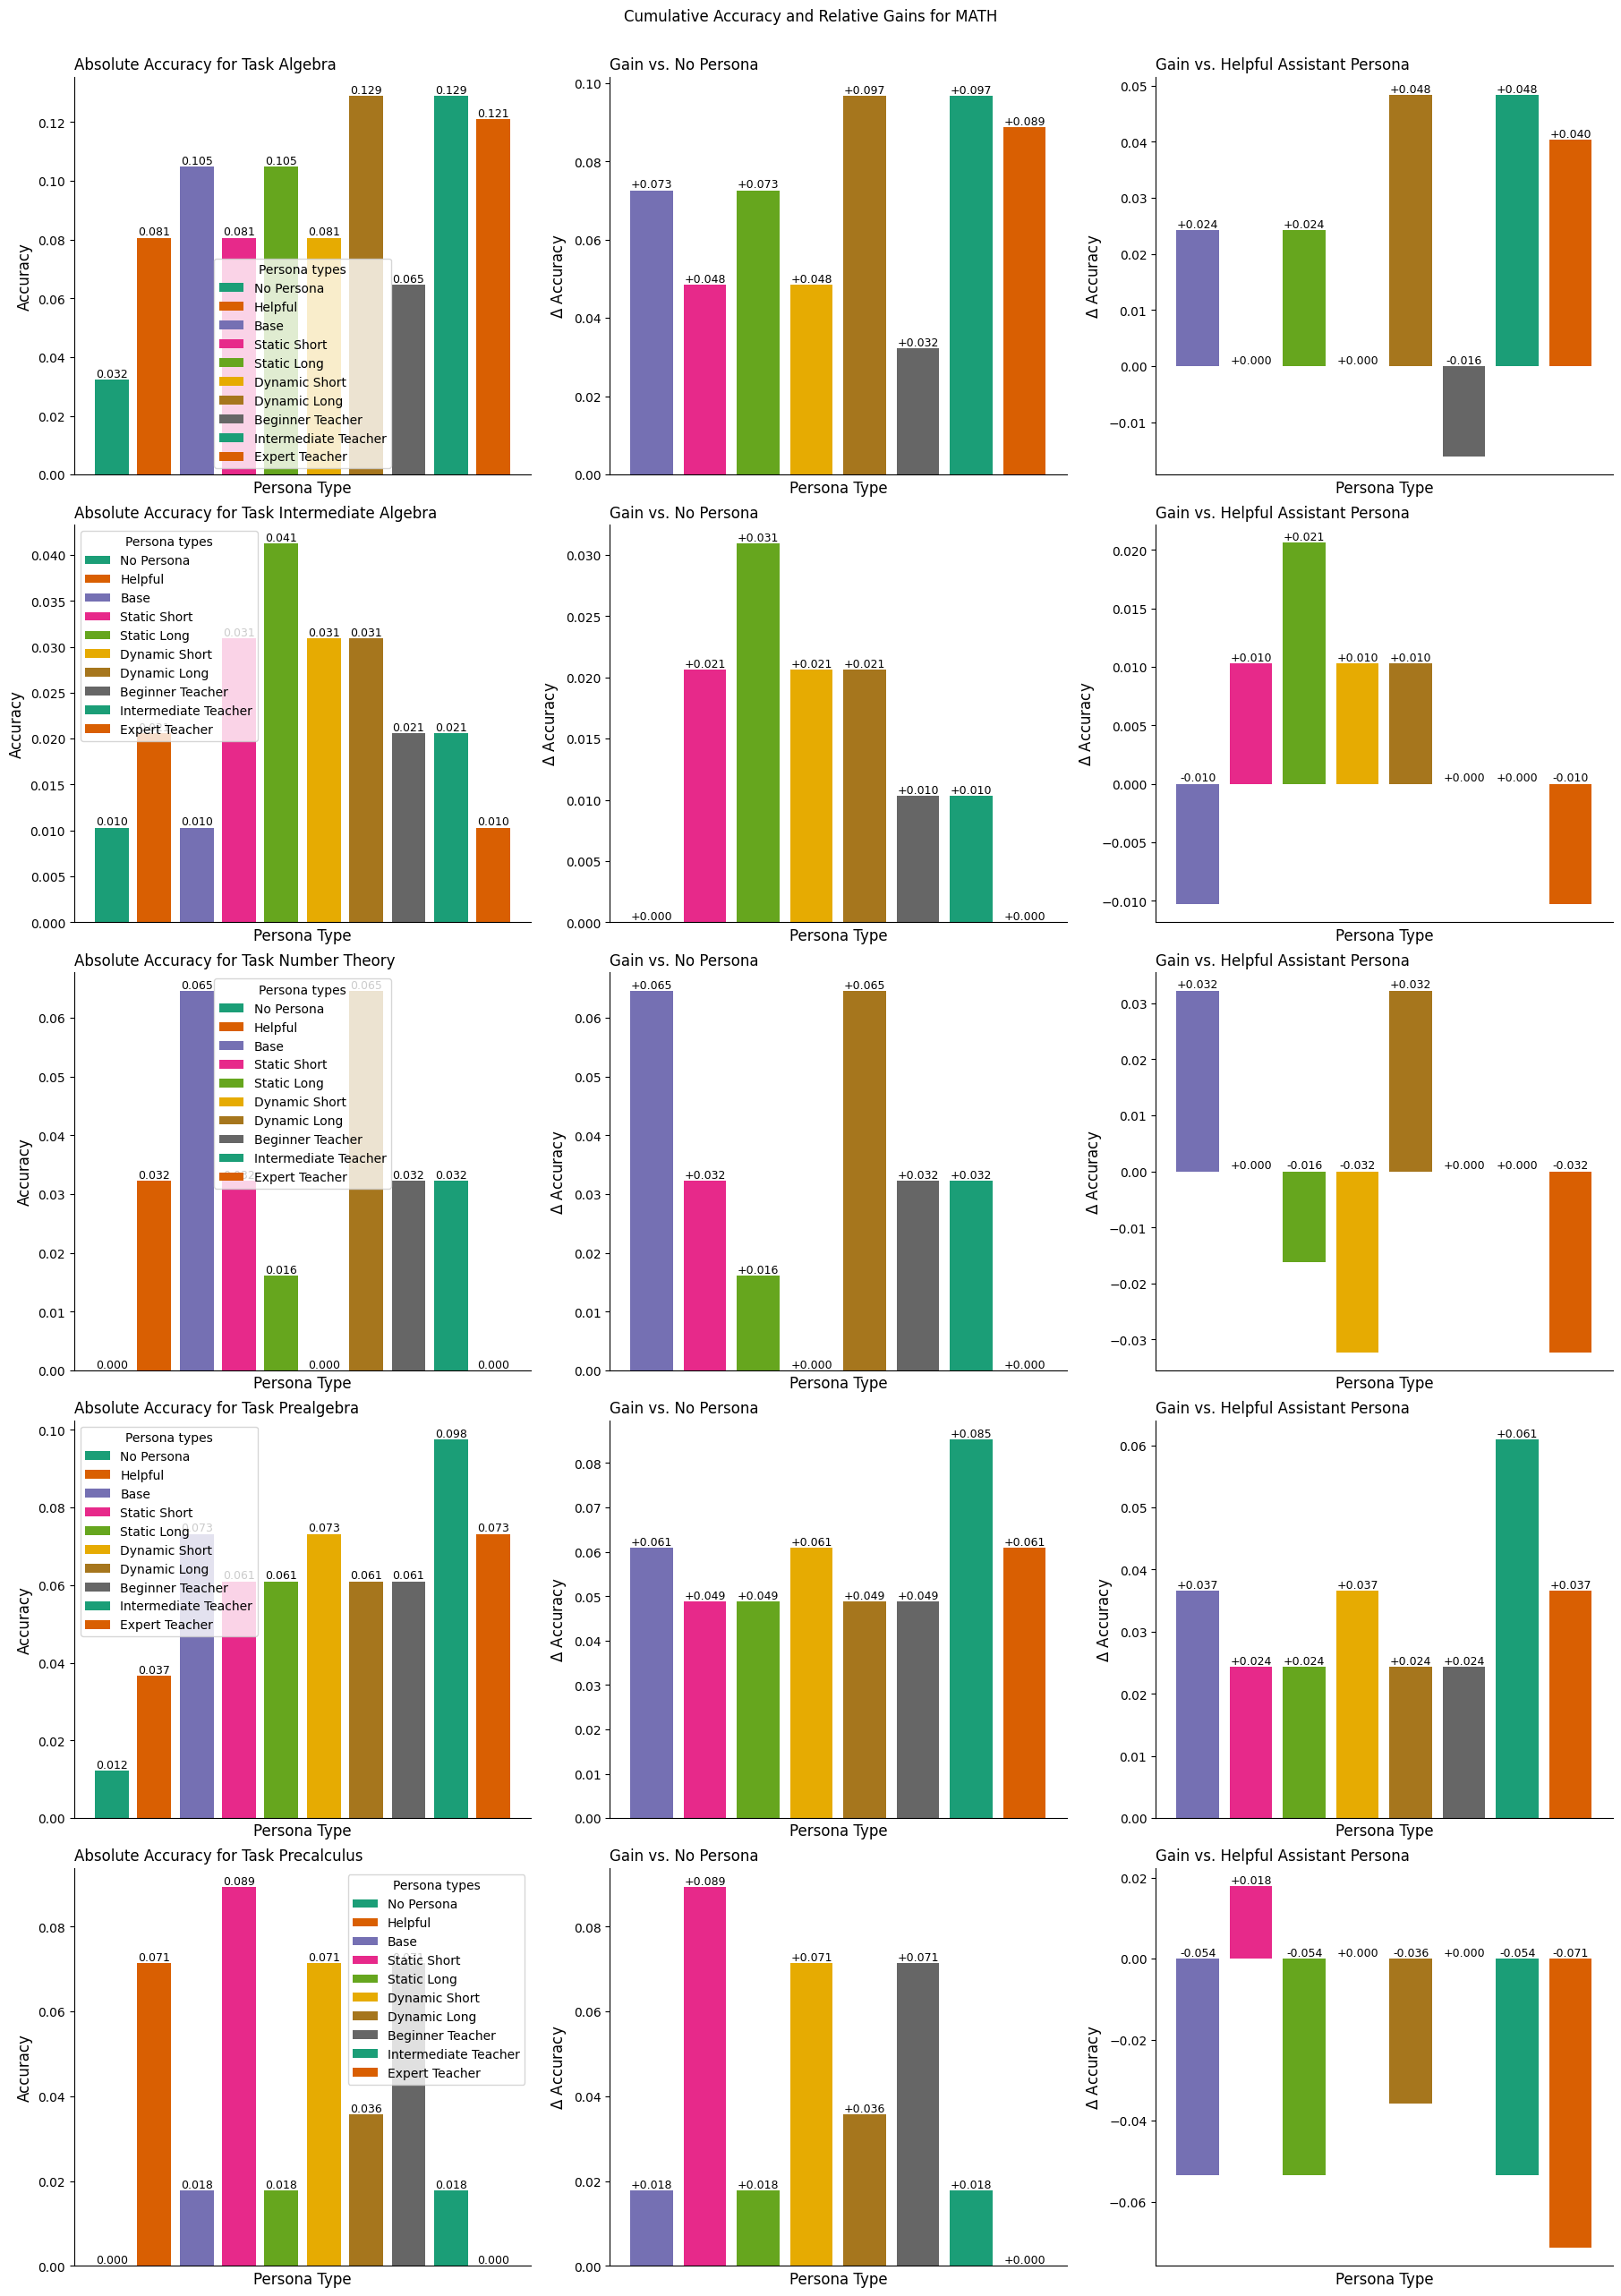

In [77]:
categories = accuracy_df["subject"].tolist()

fig, axes = plt.subplots(
    nrows=len(categories),
    ncols=3,
    figsize=(18, len(categories) * 5),
    constrained_layout=True
)

for i, category in enumerate(categories):
    row_abs = get_plot_dict(accuracy_df, category, category_col="subject")
    row_base = get_plot_dict(gains_baseline_df, category, category_col="subject", ignore_cols=["no"])
    row_help = get_plot_dict(gains_helpful_df, category, category_col="subject", ignore_cols=["helpful"])

    plotting_wrapper.plot_abs_accuracy(axes[i][0], row_abs, title=f"Absolute Accuracy for Task {category}")
    plotting_wrapper.plot_rel_accuracy(axes[i][1], row_base, title=f"Gain vs. No Persona")
    plotting_wrapper.plot_rel_accuracy(axes[i][2], row_help, title=f"Gain vs. Helpful Assistant Persona")

fig.suptitle("Cumulative Accuracy and Relative Gains for MATH", y=1.02)
fig.savefig(f"plots/math_{dataset_path}", dpi=1200)
plt.show()

In [81]:
math_effects_df = math_df.copy()
for col in completion_columns:
    eq_col = math_effects_df["answers"] == math_effects_df[col]
    math_effects_df[col] = eq_col.astype("int")

### Category Precalculus

In [82]:
run_test_categorical(math_effects_df, completion_columns, "Precalculus", category_col="subject")

0
base                    0.294418
beginner_teacher        0.431657
dynamic_long            0.431657
dynamic_short           0.035997
expert_teacher          0.793229
helpful                 0.115784
intermediate_teacher    0.793229
static_long             0.600112
static_short            0.793229
dtype: float64

In [83]:
run_test_dynamic(math_effects_df, "Precalculus", category_col="subject")

persona    0.543062
dtype: float64

In [84]:
run_test_static(math_effects_df, "Precalculus", category_col="subject")

persona    0.133578
dtype: float64

In [85]:
test_static_vs_dynamic(math_effects_df, "Precalculus", category_col="subject")

is_dynamic    0.089527
dtype: float64

### Category Intermediate Algebra

In [86]:
run_test_categorical(math_effects_df, completion_columns, "Intermediate Algebra", category_col="subject")

0
base                    0.829916
beginner_teacher        0.667473
dynamic_long            0.519298
dynamic_short           0.519298
expert_teacher          0.829916
helpful                 0.390210
intermediate_teacher    0.829916
static_long             0.519298
static_short            0.519298
dtype: float64

In [87]:
run_test_dynamic(math_effects_df, "Intermediate Algebra", category_col="subject")

persona    0.480863
dtype: float64

In [88]:
run_test_static(math_effects_df, "Intermediate Algebra", category_col="subject")

persona    0.745043
dtype: float64

In [89]:
test_static_vs_dynamic(math_effects_df, "Intermediate Algebra", category_col="subject")

is_dynamic    0.070566
dtype: float64

### Category Algebra

In [90]:
run_test_categorical(math_effects_df, completion_columns, "Algebra", category_col="subject")

0
base                    0.348783
beginner_teacher        0.348783
dynamic_long            0.851354
dynamic_short           0.453518
expert_teacher          0.189610
helpful                 1.000000
intermediate_teacher    0.260867
static_long             0.707823
static_short            0.707823
dtype: float64

In [91]:
run_test_dynamic(math_effects_df, "Algebra", category_col="subject")

persona    0.802718
dtype: float64

In [92]:
run_test_static(math_effects_df, "Algebra", category_col="subject")

persona    0.315954
dtype: float64

In [93]:
test_static_vs_dynamic(math_effects_df, "Algebra", category_col="subject")

is_dynamic    0.593028
dtype: float64

### Category Number Theory

In [94]:
run_test_categorical(math_effects_df, completion_columns, "Number Theory", category_col="subject")

0
base                    1.000000
beginner_teacher        1.000000
dynamic_long            1.000000
dynamic_short           0.581728
expert_teacher          0.581728
helpful                 0.098415
intermediate_teacher    0.782985
static_long             1.000000
static_short            0.782985
dtype: float64

In [95]:
run_test_dynamic(math_effects_df, "Number Theory", category_col="subject")

persona    0.843502
dtype: float64

In [96]:
run_test_static(math_effects_df, "Number Theory", category_col="subject")

persona    0.908462
dtype: float64

In [97]:
test_static_vs_dynamic(math_effects_df, "Number Theory", category_col="subject")

is_dynamic    0.526293
dtype: float64

### Category Prealgebra

In [98]:
run_test_categorical(math_effects_df, completion_columns, "Prealgebra", category_col="subject")

0
base                    0.181098
beginner_teacher        1.000000
dynamic_long            0.025816
dynamic_short           0.181098
expert_teacher          0.655746
helpful                 0.118694
intermediate_teacher    0.372614
static_long             0.014212
static_short            0.003760
dtype: float64

In [99]:
run_test_dynamic(math_effects_df, "Prealgebra", category_col="subject")

persona    0.287131
dtype: float64

In [100]:
run_test_static(math_effects_df, "Prealgebra", category_col="subject")

persona    0.428003
dtype: float64

In [101]:
test_static_vs_dynamic(math_effects_df, "Prealgebra", category_col="subject")

is_dynamic    0.455315
dtype: float64

## Flores Evaluation

In [83]:
flores_tasks, flores_df = evaluator.get_data("flores")
judgment_columns = persona_registry.get_judgment_columns()

# del_cols = ["helpful_judgment", "static_short_judgment", "static_long_judgment"]
# judgment_columns = [c for c in judgment_columns if c not in del_cols]

flores_answer = extract_answers(flores_df, judgment_columns, "flores")

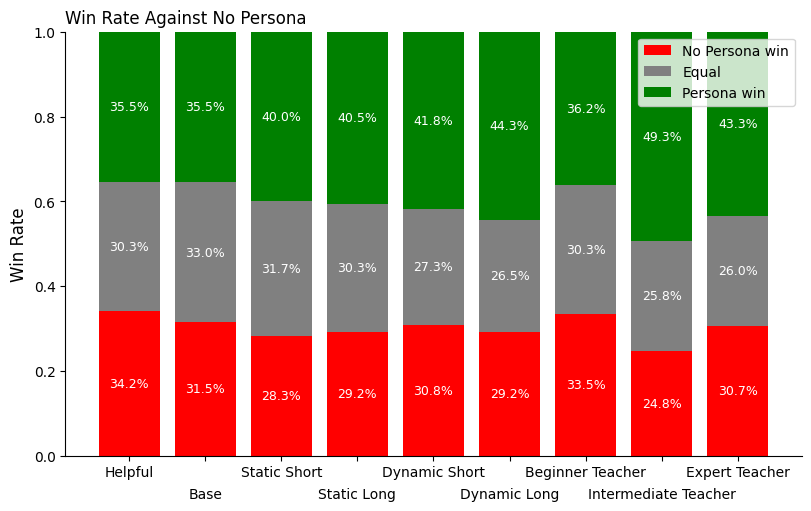

In [84]:
flores_data = get_plot_dict_cum(flores_answer, judgment_columns)

fig, axes = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8, 5),
    constrained_layout=True
)

plotting_wrapper.plot_stacked_barchart(axes, flores_data, judgment_columns, title="Win Rate Against No Persona")

# fig.suptitle(f"Win Rate against Helpful Persona on Flores+ using {GPT-5.0 nano}")
fig.savefig(f"plots/flores_{dataset_path}_averaged", dpi=1200)
plt.show()

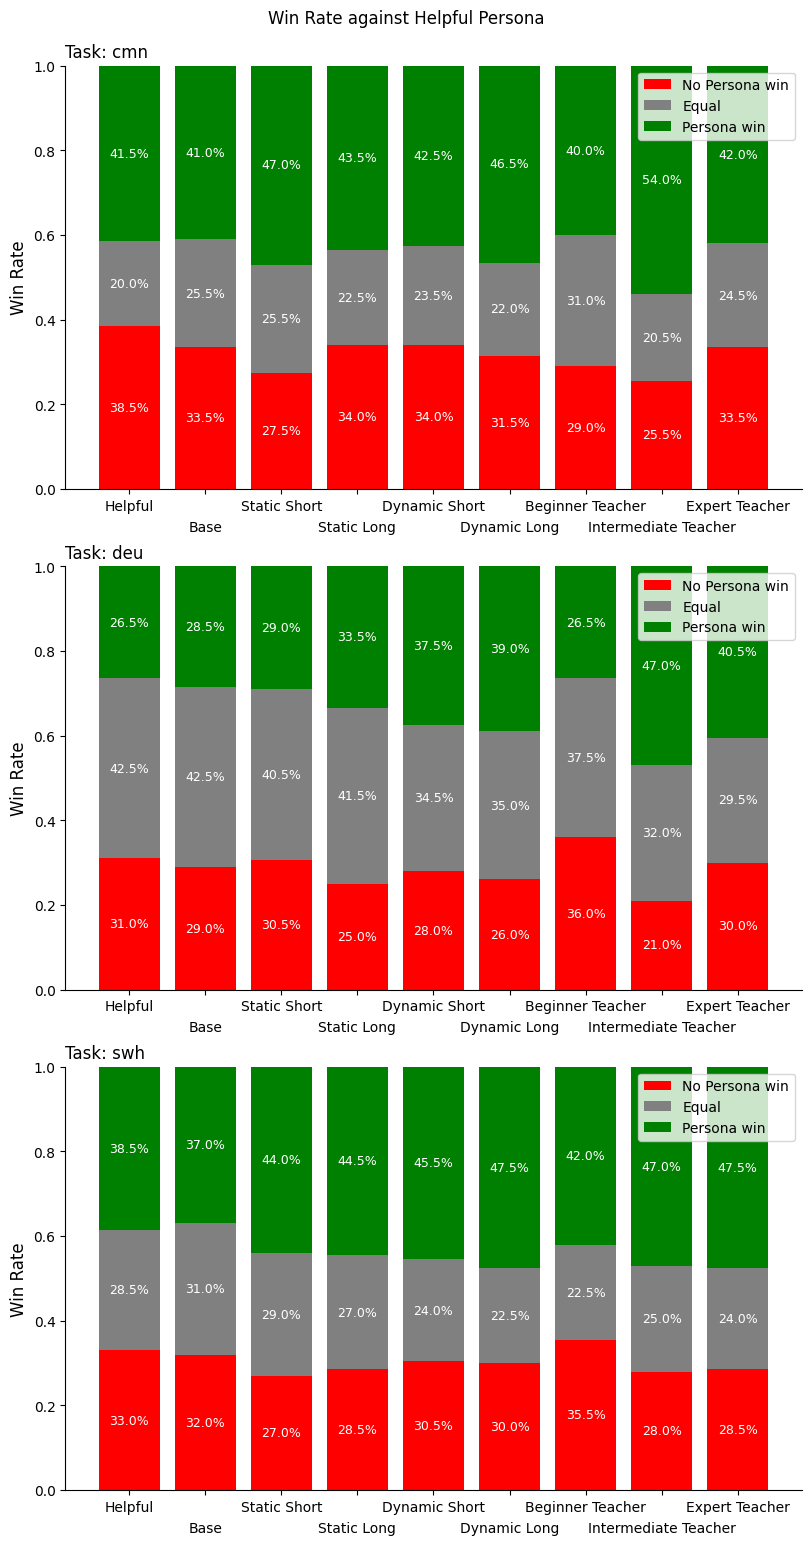

In [85]:
flores_data = get_plot_dict_stacked(flores_answer, judgment_columns, "iso_639_3")

categories = list(flores_data.keys())

fig, axes = plt.subplots(
    nrows=len(categories),
    ncols=1,
    figsize=(8, len(categories) * 5),
    constrained_layout=True
)

for ax, category in zip(axes, categories):
    category_data = flores_data[category]
    plotting_wrapper.plot_stacked_barchart(ax, category_data, judgment_columns, title=f"Task: {category}")

fig.suptitle("Win Rate against Helpful Persona", y=1.02)
fig.savefig(f"plots/flores_{dataset_path}", dpi=1200)
plt.show()

In [44]:
flores_effects_df = flores_answer.copy()
flores_effects_df["iso_639_3"].unique()

array(['cmn', 'deu', 'swh'], dtype=object)

### Category cmn

In [103]:
test_flores(flores_effects_df, completion_columns, "cmn")

base                    0.125666
beginner_teacher        0.036725
dynamic_long            0.009973
dynamic_short           0.097834
expert_teacher          0.096363
helpful                 0.346381
intermediate_teacher    0.000004
static_long             0.073999
static_short            0.000878
dtype: float64

In [104]:
run_test_dynamic(flores_effects_df, "cmn", "iso_639_3", "flores")

persona    0.35076
dtype: float64

In [105]:
run_test_static(flores_effects_df, "cmn", "iso_639_3", "flores")

persona    0.661242
dtype: float64

In [106]:
test_static_vs_dynamic(flores_effects_df, "cmn", category_col="iso_639_3", dataset_preprocess="flores")

is_dynamic    0.975085
dtype: float64

### Category deu

In [107]:
test_flores(flores_effects_df, completion_columns, "deu")

base                    0.573922
beginner_teacher        0.963393
dynamic_long            0.013972
dynamic_short           0.057727
expert_teacher          0.045885
helpful                 0.824437
intermediate_teacher    0.000005
static_long             0.069377
static_short            0.642987
dtype: float64

In [108]:
run_test_dynamic(flores_effects_df, "deu", "iso_639_3", "flores")

persona    0.098973
dtype: float64

In [109]:
run_test_static(flores_effects_df, "deu", "iso_639_3", "flores")

persona    0.116947
dtype: float64

In [110]:
test_static_vs_dynamic(flores_effects_df, "deu", category_col="iso_639_3", dataset_preprocess="flores")

is_dynamic    0.072403
dtype: float64

### Category swh

In [111]:
test_flores(flores_effects_df, completion_columns, "swh")

base                    0.221858
beginner_teacher        0.167568
dynamic_long            0.003066
dynamic_short           0.009184
expert_teacher          0.001287
helpful                 0.201552
intermediate_teacher    0.001203
static_long             0.005028
static_short            0.002715
dtype: float64

In [112]:
run_test_dynamic(flores_effects_df, "swh", "iso_639_3", "flores")

persona    0.200482
dtype: float64

In [113]:
run_test_static(flores_effects_df, "swh", "iso_639_3", "flores")

persona    0.463168
dtype: float64

In [114]:
test_static_vs_dynamic(flores_effects_df, "swh", category_col="iso_639_3", dataset_preprocess="flores")

is_dynamic    0.640035
dtype: float64